### ***Ideas to get you started:***

- Build a fraud classifier and report PR-AUC, not accuracy - then explain why.
- Which 3 signals catch the most fraud? Plot feature importance and find out.
- Tune the decision threshold: how much recall can you buy per false positive?
- Compare SMOTE, class weights and undersampling on the same model.
- Are AI-generated scam attempts harder to catch than ordinary fraud?
- Does strong authentication (biometric, 3D Secure) actually suppress fraud?
- Engineer your own velocity features from hours_since_last_txn and txn_count_last_24h.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("credit_card_fraud_2026.csv")

In [3]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  str    
 3   card_type                     20000 non-null  str    
 4   auth_method                   20000 non-null  str    
 5   channel                       20000 non-null  str    
 6   device_type                   20000 non-null  str    
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  account_bala

In [5]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head(15)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0
5,6,119.72,Gift Cards,Amex,Biometric,Contactless,iPhone,False,5.94,4,...,False,False,0,15.2,5,1,False,81.2,0,0
6,7,139.71,Electronics,RuPay,3D Secure,In-App,POS Terminal,False,18.31,6,...,False,False,1,24.5,1,3,False,63.0,0,0
7,8,340.68,Electronics,Visa,3D Secure,Online,ATM Machine,False,25.56,2,...,False,False,0,15.9,15,5,False,52.9,0,0
8,9,116.41,Groceries,Mastercard,Biometric,Online,iPhone,False,6.28,2,...,False,False,0,25.5,7,4,False,39.8,1,0
9,10,154.65,Groceries,Visa,PIN,Online,Tablet,False,0.78,5,...,False,False,0,30.7,11,5,False,38.3,0,0


In [12]:
df[df.is_fraud == 1]

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
63,64,2396.82,Crypto Exchange,Visa,OTP,ATM,Mac,False,5.37,3,...,False,False,1,11.3,5,5,False,92.0,0,1
148,149,18.34,Online Retail,Visa,3D Secure,Online,Android Phone,False,8.70,2,...,True,True,0,17.8,4,1,False,18.6,1,1
267,268,7.25,Gaming,Visa,No Authentication,ATM,Tablet,False,4.00,5,...,False,False,1,23.9,16,1,False,67.1,0,1
363,364,246.90,Crypto Exchange,Amex,OTP,POS,POS Terminal,False,5.18,1,...,False,False,2,8.2,12,0,False,85.7,0,1
391,392,576.76,Crypto Exchange,Visa,OTP,Online,POS Terminal,False,4.29,1,...,False,True,0,9.5,20,5,False,78.4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19764,19765,24.46,Restaurants,Mastercard,PIN,POS,Mac,True,2.35,5,...,True,False,2,40.9,20,1,False,32.3,0,1
19798,19799,8.73,Utilities,Visa,OTP,POS,Android Phone,False,10.99,6,...,False,False,0,27.0,5,1,False,68.9,0,1
19801,19802,31.11,Fuel,Visa,3D Secure,In-App,POS Terminal,True,1.59,3,...,True,True,1,21.8,0,2,False,7.7,0,1
19953,19954,16.62,Online Retail,Visa,OTP,Contactless,POS Terminal,True,9.20,6,...,True,False,0,36.3,20,6,False,39.9,0,1


In [18]:
df["is_fraud"].value_counts()
# df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    19661
1      339
Name: count, dtype: int64

In [16]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


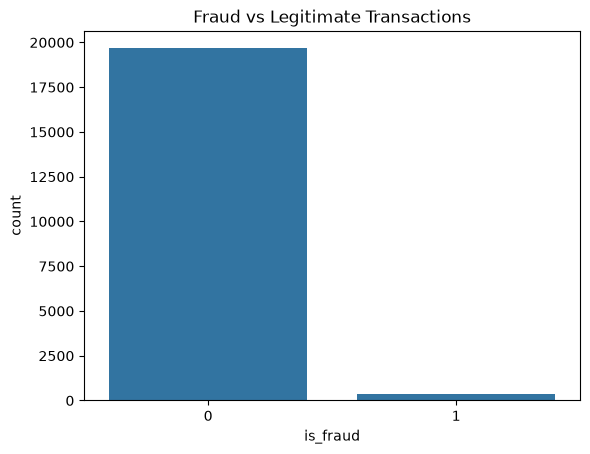

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="is_fraud")
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [20]:
fraud_by_merchant = (df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False))

print(fraud_by_merchant)

merchant_category
Crypto Exchange    0.049911
Gift Cards         0.043760
Gaming             0.036680
Electronics        0.023622
Streaming          0.020792
Utilities          0.018797
Healthcare         0.012935
Groceries          0.012338
Fuel               0.012141
Restaurants        0.011444
Travel             0.011268
Online Retail      0.009368
Name: is_fraud, dtype: float64


In [21]:
fraud_by_auth_method = (df.groupby("auth_method")["is_fraud"].mean().sort_values(ascending=False))

print(fraud_by_auth_method)

auth_method
No Authentication    0.044389
OTP                  0.015651
3D Secure            0.015484
PIN                  0.011503
Biometric            0.007759
Name: is_fraud, dtype: float64


In [23]:
fraud_by_device_type = (df.groupby("device_type")["is_fraud"].mean().sort_values(ascending=False))

print(fraud_by_device_type)

device_type
Tablet           0.018949
Android Phone    0.018899
Mac              0.018396
ATM Machine      0.017910
Smart Watch      0.017857
POS Terminal     0.017078
iPhone           0.016511
Windows PC       0.011056
Name: is_fraud, dtype: float64


In [24]:
fraud_by_channel = (df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False))

print(fraud_by_channel)

channel
Online         0.019824
ATM            0.018195
In-App         0.016124
POS            0.015219
Contactless    0.014118
Name: is_fraud, dtype: float64


In [30]:
# col = ["card_type", "auth_method", "channel", "device_type"]:
# print("\n", col)
df.groupby(["card_type", "auth_method", "channel", "device_type"])["is_fraud"].mean().sort_values(ascending=False)

card_type   auth_method        channel      device_type
Amex        Biometric          ATM          iPhone         0.500000
Discover    No Authentication  Contactless  iPhone         0.500000
Mastercard  Biometric          ATM          ATM Machine    0.500000
Discover    3D Secure          In-App       Smart Watch    0.500000
RuPay       No Authentication  Online       Mac            0.333333
                                                             ...   
Visa        PIN                Online       ATM Machine    0.000000
Amex        3D Secure          In-App       Windows PC     0.000000
                                            Tablet         0.000000
                                            Smart Watch    0.000000
Visa        PIN                In-App       iPhone         0.000000
Name: is_fraud, Length: 965, dtype: float64

In [31]:
df.groupby("is_fraud")["amount_usd"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,19661.0,131.582739,254.241020,1.00,26.21,57.35,130.88,6872.69
1,339.0,181.249853,380.460485,4.09,28.62,69.77,165.32,3356.46
